In [4]:
import pandas as pd
df=pd.read_csv('/hiring.csv')

In [5]:
import pandas as pd
import numpy as np
from sklearn import linear_model

# Assuming df is already loaded from the previous cell (df=pd.read_csv('/hiring.csv'))
# Handle 'experience' column: map word numbers to integers and fill NaNs with 0
word_to_num = {
    'one': 1, 'two': 2, 'three': 3, 'four': 4, 'five': 5,
    'six': 6, 'seven': 7, 'eight': 8, 'nine': 9, 'ten': 10,
    None: 0,
    np.nan: 0
}
df['experience'] = df['experience'].map(word_to_num).fillna(0).astype(int)

# Handle missing values in 'test_score(out of 10)' and 'interview_score(out of 10)' by filling with the median
df['test_score(out of 10)'].fillna(df['test_score(out of 10)'].median(), inplace=True)
df['interview_score(out of 10)'].fillna(df['interview_score(out of 10)'].median(), inplace=True)

# Define features (X) and target (y)
X = df[['experience', 'test_score(out of 10)', 'interview_score(out of 10)']]
y = df['salary($)']

# Create and train the linear regression model
reg = linear_model.LinearRegression()
reg.fit(X, y)

print("Multiple Linear Regression Model Trained Successfully.")
print("Coefficients:", reg.coef_)
print("Intercept:", reg.intercept_)

# Predict salaries for new candidates
# Candidate 1: 2 yr experience, 9 test score, 6 interview score
# Candidate 2: 12 yr experience, 10 test score, 10 interview score

new_candidates = pd.DataFrame({
    'experience': [2, 12],
    'test_score(out of 10)': [9, 10],
    'interview_score(out of 10)': [6, 10]
})

predicted_salaries = reg.predict(new_candidates)

print("\nPredicted Salaries for new candidates:")
for i, salary in enumerate(predicted_salaries):
    print(f"Candidate {i+1}: ${salary:,.2f}")

Multiple Linear Regression Model Trained Successfully.
Coefficients: [1570.52771324 -383.0069698  1603.05343511]
Intercept: 48091.60305343511

Predicted Salaries for new candidates:
Candidate 1: $57,403.92
Candidate 2: $79,138.40


/tmp/ipython-input-1131739090.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['test_score(out of 10)'].fillna(df['test_score(out of 10)'].median(), inplace=True)
/tmp/ipython-input-1131739090.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[c

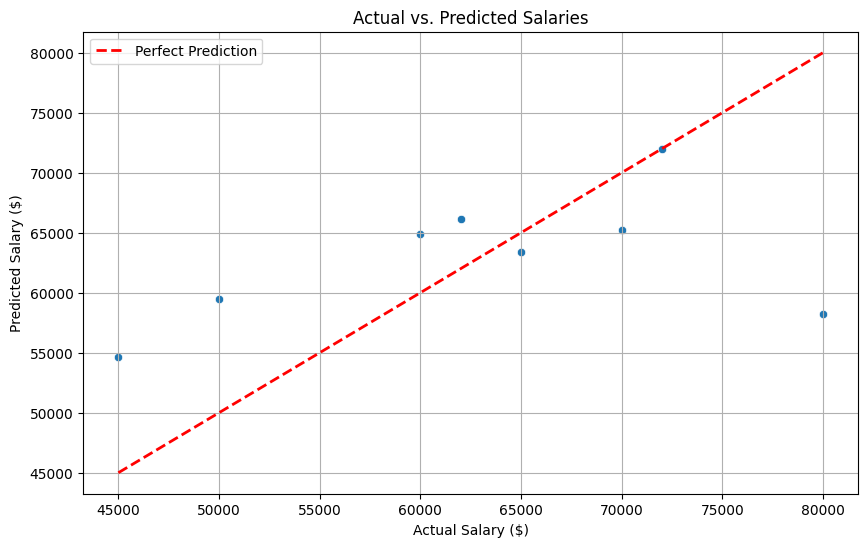

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions using the trained model on the training data for evaluation
y_pred = reg.predict(X)

# Create a DataFrame for plotting actual vs. predicted values
plot_df = pd.DataFrame({'Actual Salary': y, 'Predicted Salary': y_pred})

# Plot actual vs. predicted salaries
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Actual Salary', y='Predicted Salary', data=plot_df)
plt.title('Actual vs. Predicted Salaries')
plt.xlabel('Actual Salary ($)')
plt.ylabel('Predicted Salary ($)')
plt.grid(True)

# Add a line representing perfect prediction (y=x)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', lw=2, label='Perfect Prediction')
plt.legend()
plt.show()

In [8]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load the dataset
df_companies = pd.read_csv('/1000_Companies.csv')

# Define features (X) and target (y)
X = df_companies[['R&D Spend', 'Administration', 'Marketing Spend', 'State']]
y = df_companies['Profit']

# Identify categorical and numerical features
categorical_features = ['State']
numerical_features = ['R&D Spend', 'Administration', 'Marketing Spend']

# Create a column transformer for one-hot encoding categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep numerical features as they are
)

# Create a pipeline that first preprocesses the data and then applies linear regression
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Train the model
model.fit(X, y)

print("Multiple Linear Regression Model Trained Successfully for 1000_companies.csv.")

# Predict profit for new data
# New data: 91694.48 R&D Spend, 515841.3 Administration, 11931.24 Marketing Spend, Florida State
new_data = pd.DataFrame({
    'R&D Spend': [91694.48],
    'Administration': [515841.3],
    'Marketing Spend': [11931.24],
    'State': ['Florida']
})

predicted_profit = model.predict(new_data)

print(f"\nPredicted Profit for the new input: ${predicted_profit[0]:,.2f}")

Multiple Linear Regression Model Trained Successfully for 1000_companies.csv.

Predicted Profit for the new input: $510,570.99


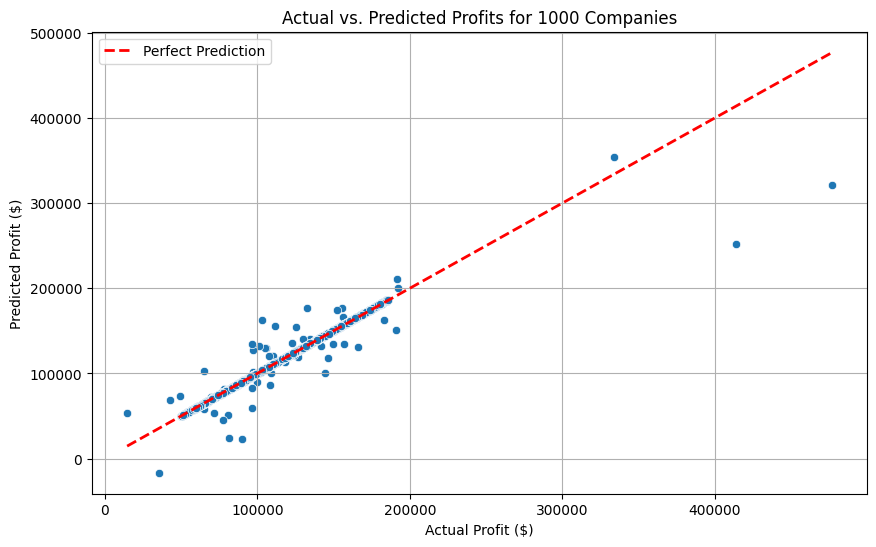

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions using the trained model on the training data for evaluation
y_pred_companies = model.predict(X)

# Create a DataFrame for plotting actual vs. predicted values
plot_df_companies = pd.DataFrame({'Actual Profit': y, 'Predicted Profit': y_pred_companies})

# Plot actual vs. predicted profits
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Actual Profit', y='Predicted Profit', data=plot_df_companies)
plt.title('Actual vs. Predicted Profits for 1000 Companies')
plt.xlabel('Actual Profit ($)')
plt.ylabel('Predicted Profit ($)')
plt.grid(True)

# Add a line representing perfect prediction (y=x)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', lw=2, label='Perfect Prediction')
plt.legend()
plt.show()